In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'intro_to_ai/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load

# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/intro_to_ai/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

Mounted at /content/drive
[Errno 2] No such file or directory: '/content/drive/My Drive/intro_to_ai/assignments/assignment1//intro_to_ai/datasets/'
/content
bash: get_datasets.sh: No such file or directory
[Errno 2] No such file or directory: '/content/drive/My Drive/intro_to_ai/assignments/assignment1/'
/content


# Table of Contents

This assignment has 5 parts. You will learn PyTorch on **three different levels of abstraction**, which will help you understand it better and prepare you for the final project.

1. Part I, Preparation: we will use CIFAR-10 dataset.
2. Part II, Barebones PyTorch: **Abstraction level 1**, we will work directly with the lowest-level PyTorch Tensors.
3. Part III, PyTorch Module API: **Abstraction level 2**, we will use `nn.Module` to define arbitrary neural network architecture.
4. Part IV, PyTorch Sequential API: **Abstraction level 3**, we will use `nn.Sequential` to define a linear feed-forward network very conveniently.
5. Part V, CIFAR-10 open-ended challenge: please implement your own network to get as high accuracy as possible on CIFAR-10. You can experiment with any layer, optimizer, hyperparameters or other advanced features.

Here is a table of comparison:

| API           | Flexibility | Convenience |
|---------------|-------------|-------------|
| Barebone      | High        | Low         |
| `nn.Module`     | High        | Medium      |
| `nn.Sequential` | Low         | High        |

# GPU

You can manually switch to a GPU device on Colab by clicking `Runtime -> Change runtime type` and selecting `GPU` under `Hardware Accelerator`. You should do this before running the following cells to import packages, since the kernel gets restarted upon switching runtimes.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler

import torchvision.datasets as dset
import torchvision.transforms as T

import numpy as np

USE_GPU = True
dtype = torch.float32 # We will be using float throughout this assignment.

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Constant to control how frequently we print train loss.
print_every = 100
print('using device:', device)

using device: cuda


# Part I. Preparation

Now, let's load the CIFAR-10 dataset. This might take a couple of minutes the first
time you run the code, but the files should stay cached afterwards.

In earlier sections of this assignment, dataset handling was performed manually.
Here, we use PyTorch's built-in utilities to load, preprocess, and iterate over
the data in minibatches.


In [ ]:
NUM_TRAIN = 49000

# The torchvision.transforms package provides tools for preprocessing data.
# Here we set up a transform that normalizes the data by subtracting the mean
# RGB value and dividing by the standard deviation of each RGB channel.
# The mean and standard deviation values are hardcoded.
transform = T.Compose([
                T.ToTensor(),
                T.Normalize((0.4914, 0.4822, 0.4465),
                            (0.2023, 0.1994, 0.2010))
            ])

# We set up a Dataset object for each split (train / val / test).
# Datasets load examples one at a time, so we wrap each Dataset in a DataLoader
# which forms minibatches. The training set is split into train and validation
# subsets using a Sampler.
cifar10_train = dset.CIFAR10('./intro_to_ai/datasets', train=True, download=True,
                             transform=transform)
loader_train = DataLoader(cifar10_train, batch_size=64,
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))

cifar10_val = dset.CIFAR10('./intro_to_ai/datasets', train=True, download=True,
                           transform=transform)
loader_val = DataLoader(cifar10_val, batch_size=64,
                        sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN, 50000)))

cifar10_test = dset.CIFAR10('./intro_to_ai/datasets', train=False, download=True,
                            transform=transform)
loader_test = DataLoader(cifar10_test, batch_size=64)


100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


# Part II. Barebones PyTorch

PyTorch ships with high-level APIs to help us define model architectures conveniently, which we will cover in Part II of this assignment. In this section, we will start with the barebone PyTorch elements to understand the autograd engine better. After this exercise, you will come to appreciate the high-level model API more.

We will start with a simple fully-connected ReLU network with two hidden layers and no biases for CIFAR classification.
This implementation computes the forward pass using operations on PyTorch Tensors, and uses PyTorch autograd to compute gradients. It is important that you understand every line, because you will write a harder version after the example.

When we create a PyTorch Tensor with `requires_grad=True`, then operations involving that Tensor will not just compute values; they will also build up a computational graph in the background, allowing us to easily backpropagate through the graph to compute gradients of some Tensors with respect to a downstream loss. Concretely if x is a Tensor with `x.requires_grad == True` then after backpropagation `x.grad` will be another Tensor holding the gradient of x with respect to the scalar loss at the end.

### PyTorch Tensors: Flatten Function
A PyTorch Tensor is conceptionally similar to a numpy array: it is an n-dimensional grid of numbers, and like numpy PyTorch provides many functions to efficiently operate on Tensors. As a simple example, we provide a `flatten` function below which reshapes image data for use in a fully-connected neural network.

Recall that image data is typically stored in a Tensor of shape N x C x H x W, where:

* N is the number of datapoints
* C is the number of channels
* H is the height of the intermediate feature map in pixels
* W is the height of the intermediate feature map in pixels

When we use fully connected affine layers to process the image, however, we want each datapoint to be represented by a single vector -- it's no longer useful to segregate the different channels, rows, and columns of the data. So, we use a "flatten" operation to collapse the `C x H x W` values per representation into a single long vector. The flatten function below first reads in the N, C, H, and W values from a given batch of data, and then returns a "view" of that data. "View" is analogous to numpy's "reshape" method: it reshapes x's dimensions to be N x ??, where ?? is allowed to be anything (in this case, it will be C x H x W, but we don't need to specify that explicitly).

In [ ]:
def flatten(x):
    N = x.shape[0] # read in N, C, H, W
    return x.view(N, -1)  # "flatten" the C * H * W values into a single vector per image

def test_flatten():
    x = torch.arange(12).view(2, 1, 3, 2)
    print('Before flattening: ', x)
    print('After flattening: ', flatten(x))

test_flatten()

Before flattening:  tensor([[[[ 0,  1],
          [ 2,  3],
          [ 4,  5]]],


        [[[ 6,  7],
          [ 8,  9],
          [10, 11]]]])
After flattening:  tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])


### Barebones PyTorch: Two-Layer Network

Here we define a function `two_layer_fc` which performs the forward pass of a two-layer fully-connected ReLU network on a batch of image data. After defining the forward pass we check that it doesn't crash and that it produces outputs of the right shape by running zeros through the network.

You don't have to write any code here, but it's important that you read and understand the implementation.

In [ ]:
import torch.nn.functional as F  # useful stateless functions

def two_layer_fc(x, params):
    """
    A fully-connected neural network; the architecture is:
    NN is fully connected -> ReLU -> fully connected layer.
    Note that this function only defines the forward pass;
    PyTorch will take care of the backward pass for us.

    The input to the network will be a minibatch of data, of shape
    (N, d1, ..., dM) where d1 * ... * dM = D. The hidden layer will have H units,
    and the output layer will produce scores for C classes.

    Inputs:
    - x: A PyTorch Tensor of shape (N, d1, ..., dM) giving a minibatch of
      input data.
    - params: A list [w1, w2] of PyTorch Tensors giving weights for the network;
      w1 has shape (D, H) and w2 has shape (H, C).

    Returns:
    - scores: A PyTorch Tensor of shape (N, C) giving classification scores for
      the input data x.
    """
    # first we flatten the image
    x = flatten(x)  # shape: [batch_size, C x H x W]

    w1, w2 = params

    # Forward pass: compute predicted y using operations on Tensors. Since w1 and
    # w2 have requires_grad=True, operations involving these Tensors will cause
    # PyTorch to build a computational graph, allowing automatic computation of
    # gradients. Since we are no longer implementing the backward pass by hand we
    # don't need to keep references to intermediate values.
    # you can also use `.clamp(min=0)`, equivalent to F.relu()
    x = F.relu(x.mm(w1))
    x = x.mm(w2)
    return x


def two_layer_fc_test():
    hidden_layer_size = 42
    x = torch.zeros((64, 50), dtype=dtype)  # minibatch size 64, feature dimension 50
    w1 = torch.zeros((50, hidden_layer_size), dtype=dtype)
    w2 = torch.zeros((hidden_layer_size, 10), dtype=dtype)
    scores = two_layer_fc(x, [w1, w2])
    print(scores.size())  # you should see [64, 10]

two_layer_fc_test()

torch.Size([64, 10])


### Barebones PyTorch: Initialization
Let's write a couple utility methods to initialize the weight matrices for our models.

- `random_weight(shape)` initializes a weight tensor with the Kaiming normalization method.
- `zero_weight(shape)` initializes a weight tensor with all zeros. Useful for instantiating bias parameters.

The `random_weight` function uses the Kaiming normal initialization method, described in:

He et al, *Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification*, ICCV 2015, https://arxiv.org/abs/1502.01852

In [ ]:
def random_weight(shape):
    """
    Create random Tensors for weights; setting requires_grad=True means that we
    want to compute gradients for these Tensors during the backward pass.
    We use Kaiming normalization: sqrt(2 / fan_in)
    """
    if len(shape) == 2:  # FC weight
        fan_in = shape[0]
    else:
        fan_in = np.prod(shape[1:]) # general fan-in computation
    # randn is standard normal distribution generator.
    w = torch.randn(shape, device=device, dtype=dtype) * np.sqrt(2. / fan_in)
    w.requires_grad = True
    return w

def zero_weight(shape):
    return torch.zeros(shape, device=device, dtype=dtype, requires_grad=True)

# create a weight of shape [3 x 5]
# you should see the type `torch.cuda.FloatTensor` if you use GPU.
# Otherwise it should be `torch.FloatTensor`
random_weight((3, 5))

tensor([[ 0.8260, -0.1958,  0.1945, -0.2635, -0.0079],
        [ 0.8759,  0.6628,  0.7868,  0.3071, -0.8011],
        [ 1.2230, -0.4285,  1.3323,  1.6092,  0.4074]], device='cuda:0',
       requires_grad=True)

### Barebones PyTorch: Check Accuracy
When training the model we will use the following function to check the accuracy of our model on the training or validation sets.

When checking accuracy we don't need to compute any gradients; as a result we don't need PyTorch to build a computational graph for us when we compute scores. To prevent a graph from being built we scope our computation under a `torch.no_grad()` context manager.

In [ ]:
def check_accuracy_part2(loader, model_fn, params):
    """
    Check the accuracy of a classification model.

    Inputs:
    - loader: A DataLoader for the data split we want to check
    - model_fn: A function that performs the forward pass of the model,
      with the signature scores = model_fn(x, params)
    - params: List of PyTorch Tensors giving parameters of the model

    Returns: Nothing, but prints the accuracy of the model
    """
    split = 'val' if loader.dataset.train else 'test'
    print('Checking accuracy on the %s set' % split)
    num_correct, num_samples = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.int64)
            scores = model_fn(x, params)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f%%)' % (num_correct, num_samples, 100 * acc))

### BareBones PyTorch: Training Loop
We can now set up a basic training loop to train our network. We will train the model using stochastic gradient descent without momentum. We will use `torch.functional.cross_entropy` to compute the loss; you can [read about it here](http://pytorch.org/docs/stable/nn.html#cross-entropy).

The training loop takes as input the neural network function, a list of initialized parameters (`[w1, w2]` in our example), and learning rate.

In [ ]:
def train_part2(model_fn, params, learning_rate):
    """
    Train a model on CIFAR-10.

    Inputs:
    - model_fn: A Python function that performs the forward pass of the model.
      It should have the signature scores = model_fn(x, params) where x is a
      PyTorch Tensor of image data, params is a list of PyTorch Tensors giving
      model weights, and scores is a PyTorch Tensor of shape (N, C) giving
      scores for the elements in x.
    - params: List of PyTorch Tensors giving weights for the model
    - learning_rate: Python scalar giving the learning rate to use for SGD

    Returns: Nothing
    """
    for t, (x, y) in enumerate(loader_train):
        # Move the data to the proper device (GPU or CPU)
        x = x.to(device=device, dtype=dtype)
        y = y.to(device=device, dtype=torch.long)

        # Forward pass: compute scores and loss
        scores = model_fn(x, params)
        loss = F.cross_entropy(scores, y)

        # Backward pass: PyTorch figures out which Tensors in the computational
        # graph has requires_grad=True and uses backpropagation to compute the
        # gradient of the loss with respect to these Tensors, and stores the
        # gradients in the .grad attribute of each Tensor.
        loss.backward()

        # Update parameters. We don't want to backpropagate through the
        # parameter updates, so we scope the updates under a torch.no_grad()
        # context manager to prevent a computational graph from being built.
        with torch.no_grad():
            for w in params:
                w -= learning_rate * w.grad

                # Manually zero the gradients after running the backward pass
                w.grad.zero_()

        if t % print_every == 0:
            print('Iteration %d, loss = %.4f' % (t, loss.item()))
            check_accuracy_part2(loader_val, model_fn, params)
            print()

### BareBones PyTorch: Train a Two-Layer Network
Now we are ready to run the training loop. We need to explicitly allocate tensors for the fully connected weights, `w1` and `w2`.

Each minibatch of CIFAR has 64 examples, so the tensor shape is `[64, 3, 32, 32]`.

After flattening, `x` shape should be `[64, 3 * 32 * 32]`. This will be the size of the first dimension of `w1`.
The second dimension of `w1` is the hidden layer size, which will also be the first dimension of `w2`.

Finally, the output of the network is a 10-dimensional vector that represents the probability distribution over 10 classes.

You do not need to tune any hyperparameters. After training for one epoch, you
should observe that the model learns non-trivial structure in the data.


In [ ]:
hidden_layer_size = 4000
learning_rate = 1e-2

w1 = random_weight((3 * 32 * 32, hidden_layer_size))
w2 = random_weight((hidden_layer_size, 10))

train_part2(two_layer_fc, [w1, w2], learning_rate)

Iteration 0, loss = 3.5450
Checking accuracy on the val set
Got 152 / 1000 correct (15.20%)

Iteration 100, loss = 1.9403
Checking accuracy on the val set
Got 335 / 1000 correct (33.50%)

Iteration 200, loss = 2.3272
Checking accuracy on the val set
Got 385 / 1000 correct (38.50%)

Iteration 300, loss = 1.7659
Checking accuracy on the val set
Got 404 / 1000 correct (40.40%)

Iteration 400, loss = 1.7214
Checking accuracy on the val set
Got 433 / 1000 correct (43.30%)

Iteration 500, loss = 1.6024
Checking accuracy on the val set
Got 436 / 1000 correct (43.60%)

Iteration 600, loss = 1.4256
Checking accuracy on the val set
Got 435 / 1000 correct (43.50%)

Iteration 700, loss = 1.9871
Checking accuracy on the val set
Got 438 / 1000 correct (43.80%)



# Part III. PyTorch Module API

Barebone PyTorch requires that we track all the parameter tensors by hand. This is fine for small networks with a few tensors, but it would be extremely inconvenient and error-prone to track tens or hundreds of tensors in larger networks.

PyTorch provides the `nn.Module` API for you to define arbitrary network architectures, while tracking every learnable parameters for you. In Part II, we implemented SGD ourselves. PyTorch also provides the `torch.optim` package that implements all the common optimizers, such as RMSProp, Adagrad, and Adam. It even supports approximate second-order methods like L-BFGS! You can refer to the [doc](http://pytorch.org/docs/master/optim.html) for the exact specifications of each optimizer.

To use the Module API, follow the steps below:

1. Subclass `nn.Module`. Give your network class an intuitive name like `TwoLayerFC`.

2. In the constructor `__init__()`, define all the layers you need as class attributes. Layer objects like `nn.Linear` are themselves `nn.Module` subclasses and contain learnable parameters, so that you don't have to instantiate the raw tensors yourself. `nn.Module` will track these internal parameters for you. Refer to the [doc](http://pytorch.org/docs/master/nn.html) to learn more about the dozens of builtin layers. **Warning**: don't forget to call the `super().__init__()` first!

3. In the `forward()` method, define the *connectivity* of your network. You should use the attributes defined in `__init__` as function calls that take tensor as input and output the "transformed" tensor. Do *not* create any new layers with learnable parameters in `forward()`! All of them must be declared upfront in `__init__`.

After you define your Module subclass, you can instantiate it as an object and call it just like the NN forward function in part II.

### Module API: Two-Layer Network
Here is a concrete example of a 2-layer fully connected network:

In [ ]:
class TwoLayerFC(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        # assign layer objects to class attributes
        self.fc1 = nn.Linear(input_size, hidden_size)
        # nn.init package contains convenient initialization methods
        # http://pytorch.org/docs/master/nn.html#torch-nn-init
        nn.init.kaiming_normal_(self.fc1.weight)
        self.fc2 = nn.Linear(hidden_size, num_classes)
        nn.init.kaiming_normal_(self.fc2.weight)

    def forward(self, x):
        # forward always defines connectivity
        x = flatten(x)
        scores = self.fc2(F.relu(self.fc1(x)))
        return scores

def test_TwoLayerFC():
    input_size = 50
    x = torch.zeros((64, input_size), dtype=dtype)  # minibatch size 64, feature dimension 50
    model = TwoLayerFC(input_size, 42, 10)
    scores = model(x)
    print(scores.size())  # you should see [64, 10]
test_TwoLayerFC()

torch.Size([64, 10])


### Module API: Check Accuracy
Given the validation or test set, we can check the classification accuracy of a neural network.

This version is slightly different from the one in part II. You don't manually pass in the parameters anymore.

In [ ]:
def check_accuracy_part34(loader, model):
    if loader.dataset.train:
        print('Checking accuracy on validation set')
    else:
        print('Checking accuracy on test set')
    num_correct = 0
    num_samples = 0
    model.eval()  # set model to evaluation mode
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.long)
            scores = model(x)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f)' % (num_correct, num_samples, 100 * acc))


### Module API: Training Loop
We also use a slightly different training loop. Rather than updating the values of the weights ourselves, we use an Optimizer object from the `torch.optim` package, which abstract the notion of an optimization algorithm and provides implementations of most of the algorithms commonly used to optimize neural networks.

In [ ]:
def train_part34(model, optimizer, epochs=1):
    """
    Train a model on CIFAR-10 using the PyTorch Module API.

    Inputs:
    - model: A PyTorch Module giving the model to train.
    - optimizer: An Optimizer object we will use to train the model
    - epochs: (Optional) A Python integer giving the number of epochs to train for

    Returns: Nothing, but prints model accuracies during training.
    """
    model = model.to(device=device)  # move the model parameters to CPU/GPU
    for e in range(epochs):
        for t, (x, y) in enumerate(loader_train):
            model.train()  # put model to training mode
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.long)

            scores = model(x)
            loss = F.cross_entropy(scores, y)

            # Zero out all of the gradients for the variables which the optimizer
            # will update.
            optimizer.zero_grad()

            # This is the backwards pass: compute the gradient of the loss with
            # respect to each  parameter of the model.
            loss.backward()

            # Actually update the parameters of the model using the gradients
            # computed by the backwards pass.
            optimizer.step()

            if t % print_every == 0:
                print('Iteration %d, loss = %.4f' % (t, loss.item()))
                check_accuracy_part34(loader_val, model)
                print()

### Module API: Train a Two-Layer Network
Now we are ready to run the training loop. In contrast to part II, we don't explicitly allocate parameter tensors anymore.

Simply pass the input size, hidden layer size, and number of classes (i.e. output size) to the constructor of `TwoLayerFC`.

You also need to define an optimizer that tracks all the learnable parameters inside `TwoLayerFC`.

You do not need to tune any hyperparameters. After training for one epoch, you
should observe that the model learns non-trivial structure in the data.


In [ ]:
hidden_layer_size = 4000
learning_rate = 1e-2
model = TwoLayerFC(3 * 32 * 32, hidden_layer_size, 10)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

train_part34(model, optimizer)

Iteration 0, loss = 3.7856
Checking accuracy on validation set
Got 155 / 1000 correct (15.50)

Iteration 100, loss = 2.2029
Checking accuracy on validation set
Got 326 / 1000 correct (32.60)

Iteration 200, loss = 2.1094
Checking accuracy on validation set
Got 337 / 1000 correct (33.70)

Iteration 300, loss = 1.7363
Checking accuracy on validation set
Got 372 / 1000 correct (37.20)

Iteration 400, loss = 1.7514
Checking accuracy on validation set
Got 395 / 1000 correct (39.50)

Iteration 500, loss = 1.4978
Checking accuracy on validation set
Got 401 / 1000 correct (40.10)

Iteration 600, loss = 1.7794
Checking accuracy on validation set
Got 405 / 1000 correct (40.50)

Iteration 700, loss = 1.7271
Checking accuracy on validation set
Got 432 / 1000 correct (43.20)



# Part IV. PyTorch Sequential API

Part III introduced the PyTorch Module API, which allows you to define arbitrary learnable layers and their connectivity.

For simple models like a stack of feed forward layers, you still need to go through 3 steps: subclass `nn.Module`, assign layers to class attributes in `__init__`, and call each layer one by one in `forward()`. Is there a more convenient way?

Fortunately, PyTorch provides a container Module called `nn.Sequential`, which merges the above steps into one. It is not as flexible as `nn.Module`, because you cannot specify more complex topology than a feed-forward stack, but it's good enough for many use cases.

### Sequential API: Two-Layer Network
Let's see how to rewrite our two-layer fully connected network example with `nn.Sequential`, and train it using the training loop defined above.

Again, you do not need to tune any hyperparameters. After one epoch of training,
you should observe that the model learns non-trivial structure in the data.


In [ ]:
# We need to wrap `flatten` function in a module in order to stack it
# in nn.Sequential
class Flatten(nn.Module):
    def forward(self, x):
        return flatten(x)

hidden_layer_size = 4000
learning_rate = 1e-2

model = nn.Sequential(
    Flatten(),
    nn.Linear(3 * 32 * 32, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, 10),
)

# you can use Nesterov momentum in optim.SGD
optimizer = optim.SGD(model.parameters(), lr=learning_rate,
                     momentum=0.9, nesterov=True)

train_part34(model, optimizer)

Iteration 0, loss = 2.3573
Checking accuracy on validation set
Got 159 / 1000 correct (15.90)

Iteration 100, loss = 1.7657
Checking accuracy on validation set
Got 420 / 1000 correct (42.00)

Iteration 200, loss = 1.8712
Checking accuracy on validation set
Got 414 / 1000 correct (41.40)

Iteration 300, loss = 1.4473
Checking accuracy on validation set
Got 394 / 1000 correct (39.40)

Iteration 400, loss = 1.6864
Checking accuracy on validation set
Got 414 / 1000 correct (41.40)

Iteration 500, loss = 1.7614
Checking accuracy on validation set
Got 443 / 1000 correct (44.30)

Iteration 600, loss = 1.8923
Checking accuracy on validation set
Got 418 / 1000 correct (41.80)

Iteration 700, loss = 1.6198
Checking accuracy on validation set
Got 443 / 1000 correct (44.30)



# Part V. CIFAR-10 open-ended challenge

In this section, you can experiment with whatever architecture you'd like on CIFAR-10.

Now it's your job to experiment with architectures, hyperparameters, loss functions, and optimizers to train a model that achieves high accuracy on the CIFAR-10 **validation** set within 10 epochs. You can use the check_accuracy and train functions from above. You can use either `nn.Module` or `nn.Sequential` API.

Describe what you did at Overleaf report.

* Layers in torch.nn package: http://pytorch.org/docs/stable/nn.html
* Activations: http://pytorch.org/docs/stable/nn.html#non-linear-activations
* Loss functions: http://pytorch.org/docs/stable/nn.html#loss-functions
* Optimizers: http://pytorch.org/docs/stable/optim.html


### Things you might try:
- **Batch normalization**: Try adding batch normalization after fully-connected
  layers. Does training become more stable or faster?
- **Network architecture**: The network above has two layers of trainable parameters. Can you do better with a deep network?
- **Regularization**: Add l2 weight regularization, or perhaps use Dropout.

### Tips for training
For each network architecture that you try, you should tune the learning rate and other hyperparameters. When doing this there are a couple important things to keep in mind:

- If the parameters are working well, you should see improvement within a few hundred iterations
- Remember the coarse-to-fine approach for hyperparameter tuning: start by testing a large range of hyperparameters for just a few training iterations to find the combinations of parameters that are working at all.
- Once you have found some sets of parameters that seem to work, search more finely around these parameters. You may need to train for more epochs.
- You should use the validation set for hyperparameter search, and save your test set for evaluating your architecture on the best parameters as selected by the validation set.

### Going above and beyond
If you are feeling adventurous there are many other features you can implement to try and improve your performance. You are **not required** to implement any of these, but don't miss the fun if you have time!

- Alternative optimizers: you can try Adam, Adagrad, RMSprop, etc.
- Alternative activation functions such as leaky ReLU, parametric ReLU, ELU, or MaxOut.
- Model ensembles
- Data augmentation
- New Architectures
  - [ResNets](https://arxiv.org/abs/1512.03385) where the input from the previous layer is added to the output.
  - [DenseNets](https://arxiv.org/abs/1608.06993) where inputs into previous layers are concatenated together.
  - [This blog has an in-depth overview](https://chatbotslife.com/resnets-highwaynets-and-densenets-oh-my-9bb15918ee32)
  - [LeNet-5](http://yann.lecun.com/exdb/publis/pdf/lecun-98.pdf) where convolutional layers and pooling are used to exploit spatial structure in images.
  - [AlexNet](https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf) which demonstrated the effectiveness of deep convolutional neural networks for large-scale image classification.
  - [This blog provides an accessible introduction to CNNs](https://cs231n.github.io/convolutional-networks/) explaining convolution, pooling, and why CNNs outperform fully-connected networks on image data.


### Have fun and happy training!

=== Coarse Experiment 1/8 ===
{'optimizer': 'Adam', 'batch_size': 128, 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.3, 'base_channels': 16, 'hidden_size': 256, 'activation': 'relu'}
Validation accuracy: 62.10%

=== Coarse Experiment 2/8 ===
{'optimizer': 'Adam', 'batch_size': 128, 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.3, 'base_channels': 32, 'hidden_size': 256, 'activation': 'relu'}
Validation accuracy: 68.30%

=== Coarse Experiment 3/8 ===
{'optimizer': 'Adam', 'batch_size': 128, 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.3, 'base_channels': 64, 'hidden_size': 256, 'activation': 'relu'}
Validation accuracy: 67.50%

=== Coarse Experiment 4/8 ===
{'optimizer': 'Adam', 'batch_size': 128, 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.3, 'base_channels': 32, 'hidden_size': 128, 'activation': 'relu'}
Validation accuracy: 65.80%

=== Coarse Experiment 5/8 ===
{'optimizer': 'Adam', 'batch_size': 128, 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.3, 'base_channe

,optimizer,batch_size,lr,weight_decay,dropout,base_channels,hidden_size,activation,stage,val_acc
0,Adam,128,0.0010,0.00010,0.30,32,512,relu,coarse,0.719
1,Adam,128,0.0010,0.00010,0.30,32,256,leaky_relu,coarse,0.706
2,Adam,128,0.0010,0.00005,0.30,32,512,relu,fine,0.688
3,Adam,128,0.0010,0.00010,0.30,32,256,relu,coarse,0.683
4,Adam,128,0.0008,0.00010,0.25,32,512,relu,fine,0.680
5,SGD,128,0.0100,0.00010,0.30,32,256,relu,coarse,0.676
6,Adam,128,0.0010,0.00010,0.30,64,256,relu,coarse,0.675
7,Adam,128,0.0010,0.00010,0.30,32,512,relu,fine,0.663
8,Adam,128,0.0010,0.00010,0.30,32,128,relu,coarse,0.658
9,Adam,128,0.0012,0.00010,0.30,32,512,relu,fine,0.632



Best final selected config:
{'optimizer': 'Adam', 'batch_size': 128, 'lr': 0.001, 'weight_decay': 5e-05, 'dropout': 0.3, 'base_channels': 32, 'hidden_size': 512, 'activation': 'relu'}


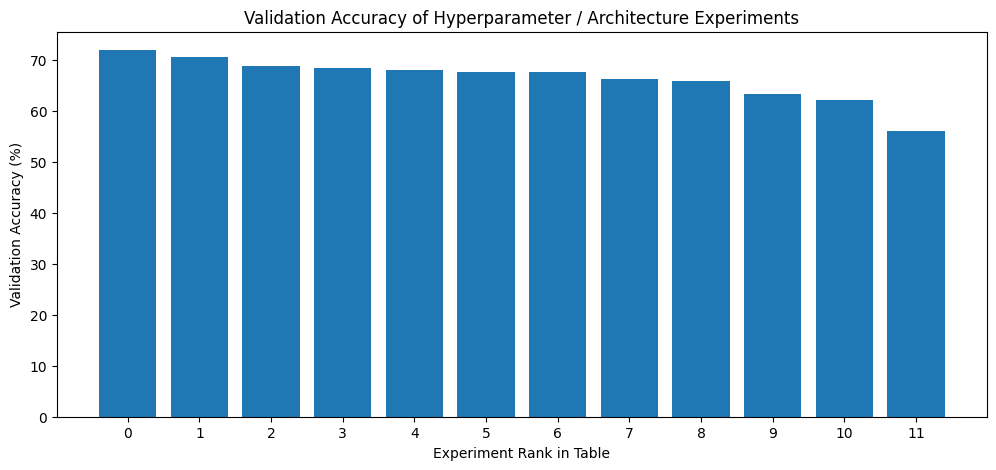

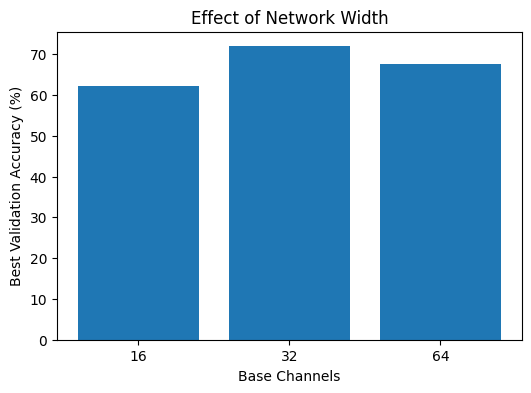

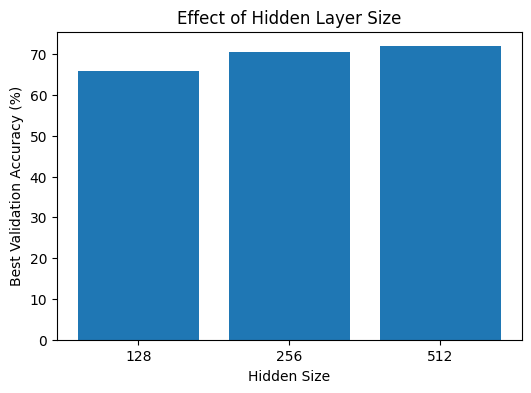

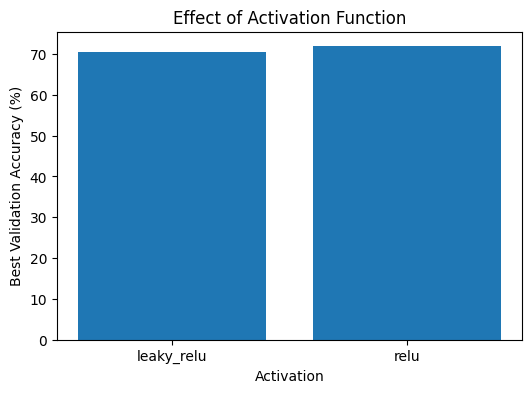

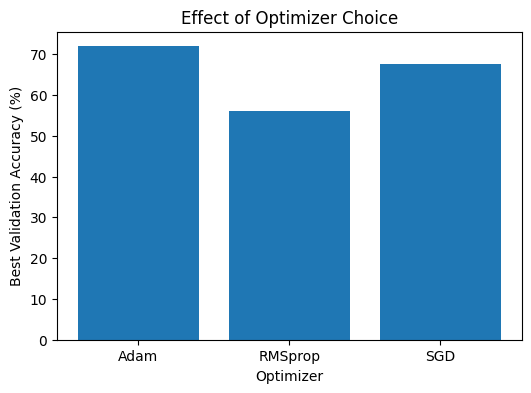

Epoch 1, Iteration 0, loss = 2.4062, val_acc = 8.20%
Epoch 1, Iteration 100, loss = 1.8136, val_acc = 35.40%
Epoch 1, Iteration 200, loss = 1.7572, val_acc = 45.00%
Epoch 1, Iteration 300, loss = 1.5368, val_acc = 44.40%
Epoch 2, Iteration 0, loss = 1.6002, val_acc = 53.30%
Epoch 2, Iteration 100, loss = 1.2270, val_acc = 58.80%
Epoch 2, Iteration 200, loss = 1.3222, val_acc = 57.50%
Epoch 2, Iteration 300, loss = 1.1818, val_acc = 62.90%
Epoch 3, Iteration 0, loss = 1.1439, val_acc = 61.80%
Epoch 3, Iteration 100, loss = 1.1705, val_acc = 63.90%
Epoch 3, Iteration 200, loss = 1.1049, val_acc = 66.60%
Epoch 3, Iteration 300, loss = 1.0203, val_acc = 66.50%
Epoch 4, Iteration 0, loss = 0.8977, val_acc = 68.80%
Epoch 4, Iteration 100, loss = 1.0722, val_acc = 65.20%
Epoch 4, Iteration 200, loss = 0.9011, val_acc = 71.70%
Epoch 4, Iteration 300, loss = 0.9362, val_acc = 71.90%
Epoch 5, Iteration 0, loss = 0.8999, val_acc = 70.60%
Epoch 5, Iteration 100, loss = 0.9484, val_acc = 72.80%
Epo

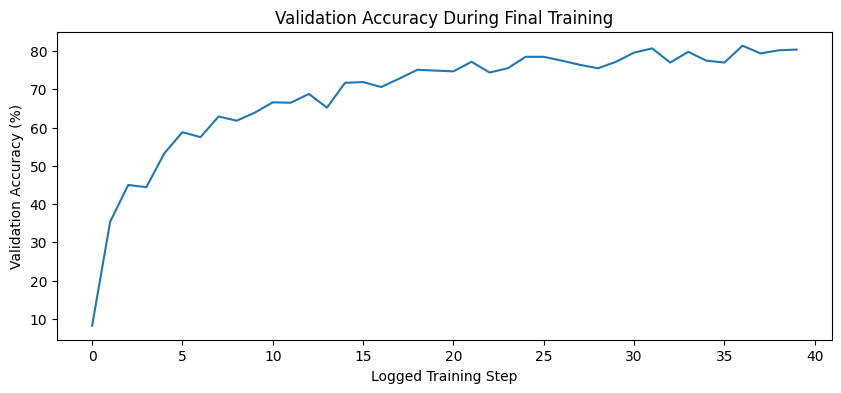

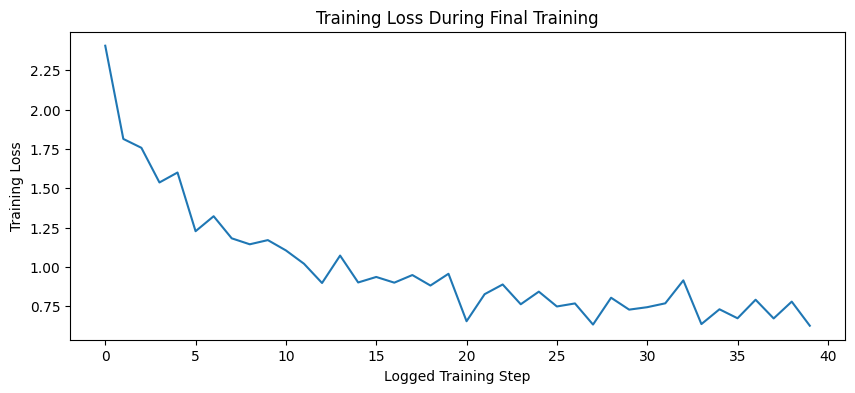


Best configuration used for final training:


,optimizer,batch_size,lr,weight_decay,dropout,base_channels,hidden_size,activation
0,Adam,128,0.001,0.00005,0.3,32,512,relu


Best validation accuracy achieved: 81.40%

Top 5 search results:


,optimizer,batch_size,lr,weight_decay,dropout,base_channels,hidden_size,activation,stage,val_acc
0,Adam,128,0.0010,0.00010,0.30,32,512,relu,coarse,0.719
1,Adam,128,0.0010,0.00010,0.30,32,256,leaky_relu,coarse,0.706
2,Adam,128,0.0010,0.00005,0.30,32,512,relu,fine,0.688
3,Adam,128,0.0010,0.00010,0.30,32,256,relu,coarse,0.683
4,Adam,128,0.0008,0.00010,0.25,32,512,relu,fine,0.680


Iteration 0, loss = 0.4667
Checking accuracy on validation set
Got 817 / 1000 correct (81.70)

Iteration 100, loss = 0.7651
Checking accuracy on validation set
Got 809 / 1000 correct (80.90)

Iteration 200, loss = 0.6047
Checking accuracy on validation set
Got 800 / 1000 correct (80.00)

Iteration 300, loss = 0.6918
Checking accuracy on validation set
Got 794 / 1000 correct (79.40)

Iteration 0, loss = 0.7410
Checking accuracy on validation set
Got 817 / 1000 correct (81.70)

Iteration 100, loss = 0.5325
Checking accuracy on validation set
Got 798 / 1000 correct (79.80)

Iteration 200, loss = 0.7128
Checking accuracy on validation set
Got 813 / 1000 correct (81.30)

Iteration 300, loss = 0.6680
Checking accuracy on validation set
Got 828 / 1000 correct (82.80)

Iteration 0, loss = 0.4968
Checking accuracy on validation set
Got 819 / 1000 correct (81.90)

Iteration 100, loss = 0.6260
Checking accuracy on validation set
Got 821 / 1000 correct (82.10)

Iteration 200, loss = 0.7475
Checkin

In [ ]:
################################################################################
# TODO:                                                                        #
# Experiment with any architectures, optimizers, and hyperparameters.          #
# Achieve high accuracy on the *validation set* within 10 epochs.              #
#                                                                              #
# Note that you can use the check_accuracy function to evaluate on either      #
# the test set or the validation set, by passing either loader_test or         #
# loader_val as the second argument to check_accuracy. You should not touch    #
# the test set until you have finished your architecture and  hyperparameter   #
# tuning, and only run the test set once at the end to report a final value.   #
################################################################################
import copy
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torchvision.datasets as dset
import torchvision.transforms as T


#גata transforms and loaders


train_transform = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2023, 0.1994, 0.2010))
])

val_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2023, 0.1994, 0.2010))
])

def make_loaders(batch_size):
    cifar10_train_local = dset.CIFAR10(
        './intro_to_ai/datasets',
        train=True,
        download=True,
        transform=train_transform
    )

    cifar10_val_local = dset.CIFAR10(
        './intro_to_ai/datasets',
        train=True,
        download=True,
        transform=val_transform
    )

    loader_train_local = DataLoader(
        cifar10_train_local,
        batch_size=batch_size,
        sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN))
    )

    loader_val_local = DataLoader(
        cifar10_val_local,
        batch_size=batch_size,
        sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN, 50000))
    )

    return loader_train_local, loader_val_local


#architecture choices


class CIFAR10_CNN(nn.Module):
    def __init__(self, base_channels=32, hidden_size=256, dropout=0.3, activation='relu'):
        super().__init__()

        def act_layer():
            if activation == 'relu':
                return nn.ReLU(inplace=True)
            elif activation == 'leaky_relu':
                return nn.LeakyReLU(0.1, inplace=True)
            elif activation == 'elu':
                return nn.ELU(inplace=True)
            else:
                raise ValueError(f"Unsupported activation: {activation}")

        self.features = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_channels),
            act_layer(),

            nn.Conv2d(base_channels, base_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_channels),
            act_layer(),
            nn.MaxPool2d(2),
            nn.Dropout(dropout),

            nn.Conv2d(base_channels, 2 * base_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(2 * base_channels),
            act_layer(),

            nn.Conv2d(2 * base_channels, 2 * base_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(2 * base_channels),
            act_layer(),
            nn.MaxPool2d(2),
            nn.Dropout(dropout),

            nn.Conv2d(2 * base_channels, 4 * base_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(4 * base_channels),
            act_layer(),

            nn.Conv2d(4 * base_channels, 4 * base_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(4 * base_channels),
            act_layer(),
            nn.MaxPool2d(2),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4 * base_channels * 4 * 4, hidden_size),
            act_layer(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



#accuracy and optimizer helpers


def get_accuracy(loader, model):
    model.eval()
    num_correct = 0
    num_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=torch.long)

            scores = model(x)
            preds = scores.argmax(dim=1)

            num_correct += (preds == y).sum().item()
            num_samples += y.size(0)

    return num_correct / num_samples


def make_optimizer(model, config):
    name = config["optimizer"]

    if name == "Adam":
        return optim.Adam(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )
    elif name == "SGD":
        return optim.SGD(
            model.parameters(),
            lr=config["lr"],
            momentum=0.9,
            nesterov=True,
            weight_decay=config["weight_decay"]
        )
    elif name == "RMSprop":
        return optim.RMSprop(
            model.parameters(),
            lr=config["lr"],
            momentum=0.9,
            weight_decay=config["weight_decay"]
        )
    else:
        raise ValueError(f"Unsupported optimizer: {name}")



#search training


def train_for_search(model, optimizer, loader_train_local, loader_val_local, epochs=3):
    model = model.to(device=device)
    best_val = 0.0

    for e in range(epochs):
        model.train()
        for x, y in loader_train_local:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=torch.long)

            scores = model(x)
            loss = F.cross_entropy(scores, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_acc = get_accuracy(loader_val_local, model)
        best_val = max(best_val, val_acc)

    return best_val


#search 1


coarse_search = [
    # architecture comparisons
    {"optimizer":"Adam", "batch_size":128, "lr":1e-3, "weight_decay":1e-4, "dropout":0.30, "base_channels":16, "hidden_size":256, "activation":"relu"},
    {"optimizer":"Adam", "batch_size":128, "lr":1e-3, "weight_decay":1e-4, "dropout":0.30, "base_channels":32, "hidden_size":256, "activation":"relu"},
    {"optimizer":"Adam", "batch_size":128, "lr":1e-3, "weight_decay":1e-4, "dropout":0.30, "base_channels":64, "hidden_size":256, "activation":"relu"},

    {"optimizer":"Adam", "batch_size":128, "lr":1e-3, "weight_decay":1e-4, "dropout":0.30, "base_channels":32, "hidden_size":128, "activation":"relu"},
    {"optimizer":"Adam", "batch_size":128, "lr":1e-3, "weight_decay":1e-4, "dropout":0.30, "base_channels":32, "hidden_size":512, "activation":"relu"},

    {"optimizer":"Adam", "batch_size":128, "lr":1e-3, "weight_decay":1e-4, "dropout":0.30, "base_channels":32, "hidden_size":256, "activation":"leaky_relu"},

    # optimizer comparisons
    {"optimizer":"SGD", "batch_size":128, "lr":1e-2, "weight_decay":1e-4, "dropout":0.30, "base_channels":32, "hidden_size":256, "activation":"relu"},
    {"optimizer":"RMSprop", "batch_size":128, "lr":5e-4, "weight_decay":1e-4, "dropout":0.30, "base_channels":32, "hidden_size":256, "activation":"relu"},
]

coarse_results = []
best_config = None
best_val_acc = -1

for i, config in enumerate(coarse_search):
    print(f"=== Coarse Experiment {i+1}/{len(coarse_search)} ===")
    print(config)

    loader_train_local, loader_val_local = make_loaders(config["batch_size"])

    candidate_model = CIFAR10_CNN(
        base_channels=config["base_channels"],
        hidden_size=config["hidden_size"],
        dropout=config["dropout"],
        activation=config["activation"]
    )

    candidate_optimizer = make_optimizer(candidate_model, config)

    val_acc = train_for_search(
        candidate_model,
        candidate_optimizer,
        loader_train_local,
        loader_val_local,
        epochs=3
    )

    result = config.copy()
    result["stage"] = "coarse"
    result["val_acc"] = val_acc
    coarse_results.append(result)

    print(f"Validation accuracy: {100 * val_acc:.2f}%\n")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_config = config.copy()

print("Best coarse config:")
print(best_config)
print(f"Best coarse validation accuracy: {100 * best_val_acc:.2f}%")



#search 2

fine_search = [
    {
        "optimizer": best_config["optimizer"],
        "batch_size": best_config["batch_size"],
        "lr": best_config["lr"] * 0.8,
        "weight_decay": best_config["weight_decay"],
        "dropout": max(0.20, best_config["dropout"] - 0.05),
        "base_channels": best_config["base_channels"],
        "hidden_size": best_config["hidden_size"],
        "activation": best_config["activation"]
    },
    {
        "optimizer": best_config["optimizer"],
        "batch_size": best_config["batch_size"],
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"],
        "dropout": best_config["dropout"],
        "base_channels": best_config["base_channels"],
        "hidden_size": best_config["hidden_size"],
        "activation": best_config["activation"]
    },
    {
        "optimizer": best_config["optimizer"],
        "batch_size": best_config["batch_size"],
        "lr": best_config["lr"] * 1.2,
        "weight_decay": best_config["weight_decay"],
        "dropout": best_config["dropout"],
        "base_channels": best_config["base_channels"],
        "hidden_size": best_config["hidden_size"],
        "activation": best_config["activation"]
    },
    {
        "optimizer": best_config["optimizer"],
        "batch_size": best_config["batch_size"],
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"] * 0.5,
        "dropout": best_config["dropout"],
        "base_channels": best_config["base_channels"],
        "hidden_size": best_config["hidden_size"],
        "activation": best_config["activation"]
    },
]

fine_results = []
best_fine_config = None
best_fine_val_acc = -1

for i, config in enumerate(fine_search):
    print(f"=== Fine Experiment {i+1}/{len(fine_search)} ===")
    print(config)

    loader_train_local, loader_val_local = make_loaders(config["batch_size"])

    candidate_model = CIFAR10_CNN(
        base_channels=config["base_channels"],
        hidden_size=config["hidden_size"],
        dropout=config["dropout"],
        activation=config["activation"]
    )

    candidate_optimizer = make_optimizer(candidate_model, config)

    val_acc = train_for_search(
        candidate_model,
        candidate_optimizer,
        loader_train_local,
        loader_val_local,
        epochs=3
    )

    result = config.copy()
    result["stage"] = "fine"
    result["val_acc"] = val_acc
    fine_results.append(result)

    print(f"Validation accuracy: {100 * val_acc:.2f}%\n")

    if val_acc > best_fine_val_acc:
        best_fine_val_acc = val_acc
        best_fine_config = config.copy()

print("Best fine config:")
print(best_fine_config)
print(f"Best fine validation accuracy: {100 * best_fine_val_acc:.2f}%")



#summary table


search_results = pd.DataFrame(coarse_results + fine_results)
search_results = search_results.sort_values("val_acc", ascending=False).reset_index(drop=True)

print("\nTop search results:")
display(search_results)

print("\nBest final selected config:")
print(best_fine_config)



#graphs

#validation accuracy by experiment
plt.figure(figsize=(12, 5))
plt.bar(range(len(search_results)), search_results["val_acc"] * 100)
plt.xticks(range(len(search_results)), search_results.index, rotation=0)
plt.ylabel("Validation Accuracy (%)")
plt.xlabel("Experiment Rank in Table")
plt.title("Validation Accuracy of Hyperparameter / Architecture Experiments")
plt.show()

# architecture
arch_summary = search_results.groupby("base_channels", as_index=False)["val_acc"].max()
plt.figure(figsize=(6, 4))
plt.bar(arch_summary["base_channels"].astype(str), arch_summary["val_acc"] * 100)
plt.xlabel("Base Channels")
plt.ylabel("Best Validation Accuracy (%)")
plt.title("Effect of Network Width")
plt.show()

hidden_summary = search_results.groupby("hidden_size", as_index=False)["val_acc"].max()
plt.figure(figsize=(6, 4))
plt.bar(hidden_summary["hidden_size"].astype(str), hidden_summary["val_acc"] * 100)
plt.xlabel("Hidden Size")
plt.ylabel("Best Validation Accuracy (%)")
plt.title("Effect of Hidden Layer Size")
plt.show()

activation_summary = search_results.groupby("activation", as_index=False)["val_acc"].max()
plt.figure(figsize=(6, 4))
plt.bar(activation_summary["activation"], activation_summary["val_acc"] * 100)
plt.xlabel("Activation")
plt.ylabel("Best Validation Accuracy (%)")
plt.title("Effect of Activation Function")
plt.show()

optimizer_summary = search_results.groupby("optimizer", as_index=False)["val_acc"].max()
plt.figure(figsize=(6, 4))
plt.bar(optimizer_summary["optimizer"], optimizer_summary["val_acc"] * 100)
plt.xlabel("Optimizer")
plt.ylabel("Best Validation Accuracy (%)")
plt.title("Effect of Optimizer Choice")
plt.show()



#final model training


loader_train, loader_val = make_loaders(best_fine_config["batch_size"])

model = CIFAR10_CNN(
    base_channels=best_fine_config["base_channels"],
    hidden_size=best_fine_config["hidden_size"],
    dropout=best_fine_config["dropout"],
    activation=best_fine_config["activation"]
)

optimizer = make_optimizer(model, best_fine_config)

def train_part34_save_best(model, optimizer, epochs=10):
    model = model.to(device=device)
    best_val_acc = -1
    best_state = None
    training_history = []

    for e in range(epochs):
        for t, (x, y) in enumerate(loader_train):
            model.train()
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=torch.long)

            scores = model(x)
            loss = F.cross_entropy(scores, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if t % print_every == 0:
                val_acc = get_accuracy(loader_val, model)
                training_history.append({
                    "epoch": e,
                    "iteration": t,
                    "loss": loss.item(),
                    "val_acc": val_acc
                })

                print(f"Epoch {e+1}, Iteration {t}, loss = {loss.item():.4f}, val_acc = {100*val_acc:.2f}%")

                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"\nBest validation accuracy during final training: {100 * best_val_acc:.2f}%")
    return model, pd.DataFrame(training_history), best_val_acc



#final run


model, training_history_df, best_validation_accuracy = train_part34_save_best(model, optimizer, epochs=10)

best_model = model



#graphs


plt.figure(figsize=(10, 4))
plt.plot(training_history_df.index, training_history_df["val_acc"] * 100)
plt.xlabel("Logged Training Step")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy During Final Training")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(training_history_df.index, training_history_df["loss"])
plt.xlabel("Logged Training Step")
plt.ylabel("Training Loss")
plt.title("Training Loss During Final Training")
plt.show()



#summary table


print("\nBest configuration used for final training:")
best_config_df = pd.DataFrame([best_fine_config])
display(best_config_df)

print(f"Best validation accuracy achieved: {100 * best_validation_accuracy:.2f}%")

print("\nTop 5 search results:")
display(search_results.head(5))
################################################################################
#                                 END OF YOUR CODE                             #
################################################################################

train_part34(model, optimizer, epochs=10)

## Test set -- run this only once

Now that we've gotten a result we're happy with, we test our final model on the test set (which you should store in best_model). Think about how this compares to your validation set accuracy.

In [ ]:
best_model = model

check_accuracy_part34(loader_test, best_model)

Checking accuracy on test set
Got 8274 / 10000 correct (82.74)
